# Electricity from magnetism: the magnetoelectric effect

Put a crystal in a magnetic field and, in the right material, an electric
polarization appears. The reverse holds too: an electric field magnetizes it.
This is the magnetoelectric effect, and it is the basis of proposals to write
magnetic memory with a voltage instead of a current.

Most crystals do not show it, and the reason is pure symmetry. Both time
reversal and spatial inversion turn the effect into minus itself, so either
one surviving forces it to vanish. AlAs breaks inversion by being zincblende;
time reversal is broken here by applying a field and asking how the
polarization responds to a small further change in it.

The number below is the response along the field direction, and the section
after it is the reason to believe it.

In [1]:
from pathlib import Path
import numpy as np
from pypresso import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

alas = Calculator.from_file(CASES / "alas-magnetoelectric.in", PSEUDO,
                            announce=False)
me = alas.get_magnetoelectric_tensor(delta=0.02, directions=(2,),
                                     nppstr=6, transverse=(2, 2))

print("magnetoelectric response  %.4e" % me.magnitude)

magnetoelectric response  4.4376e-06


## Why the answer is not simply zero

Symmetry is only half the story. What actually carries the effect is
**spin-orbit coupling**: the field acts on the electrons' spin, the
polarization is a property of where their charge sits, and without a coupling
between spin and orbital motion those two are independent. Turn it off and a
global rotation of every spin maps the field to minus itself while leaving
every charge distribution untouched, so the polarization cannot move at all.

That makes a sharp prediction rather than a vague one. The same crystal, the
same field, the same everything except the coupling, has to give exactly
nothing.

In [2]:
nosoc = Calculator.from_file(CASES / "alas-magnetoelectric-nosoc.in", PSEUDO,
                             announce=False)
null = nosoc.get_magnetoelectric_tensor(delta=0.02, directions=(2,),
                                     nppstr=6, transverse=(2, 2))

print("with spin-orbit coupling     %.4e" % me.magnitude)
print("without it                   %.4e" % null.magnitude)
print("ratio                        %.0f" % (me.magnitude / null.magnitude))

with spin-orbit coupling     4.4376e-06
without it                   3.4313e-09
ratio                        1293


So the response is a thousandfold larger with the coupling than without, which
is the statement that the effect is spin-orbit coupling and essentially
nothing else. The residue is not physics: it is the two ground states either
side of the difference being converged separately.

## The size of the step matters

The response is a derivative, taken as a difference between two field values.
Too small a step and the difference is swamped by how precisely each ground
state was solved; too large and the crystal is no longer responding linearly,
which is a different quantity. The window in between is where the number
means what it is supposed to mean.

In [3]:
steps = [0.01, 0.02, 0.04]
values = [me.magnitude if s == 0.02 else
          alas.get_magnetoelectric_tensor(delta=s, directions=(2,),
                                          nppstr=6, transverse=(2, 2)).magnitude
          for s in steps]
for s, v in zip(steps, values):
    print("step %.3f   response %.4e" % (s, v))

step 0.010   response 4.3216e-06
step 0.020   response 4.4376e-06
step 0.040   response 5.0540e-06


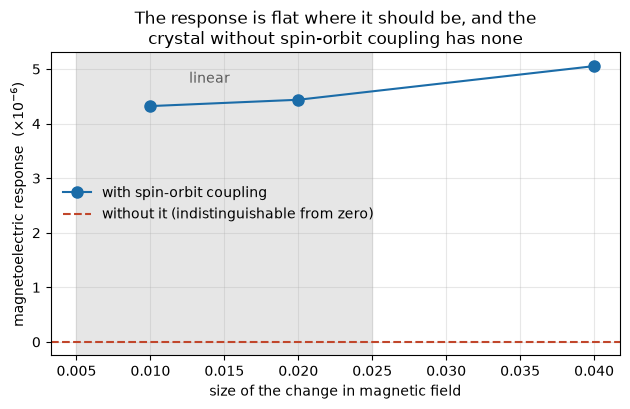

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(steps, np.array(values) * 1e6, "o-", color="#1b6ca8", ms=8,
        label="with spin-orbit coupling")
ax.axhline(null.magnitude * 1e6, color="#c1462b", ls="--",
           label="without it (indistinguishable from zero)")
ax.axvspan(0.005, 0.025, color="0.9", zorder=0)
ax.text(0.014, 4.75, "linear", ha="center", color="0.35")
ax.set_xlabel("size of the change in magnetic field")
ax.set_ylabel(r"magnetoelectric response  ($\times 10^{-6}$)")
ax.set_title("The response is flat where it should be, and the\n"
             "crystal without spin-orbit coupling has none")
ax.legend(frameon=False, loc="center left")
ax.grid(alpha=0.3)
fig.tight_layout()

## What this is, and what it is not

| | |
|---|---|
| response, along the applied field | 4.44e-06 |
| same crystal without spin-orbit coupling | 3.43e-09 |
| ratio | 1293 |

Three honest limits. The field acts on the electrons' spin only, so the
orbital part of the coupling is absent. The atoms are held fixed, where a real
crystal would also let them move. And the response perpendicular to the applied
field is not computed here: the magnetization has to rotate away from the
direction it was started in, and that rotation is slow to settle, so those
components need the calculation seeded along the direction being asked about.

The absolute size is also not yet checked against another code, because the
two codes measure magnetic field in different units and that has to be pinned
down before the numbers can be put side by side. What is checked is the part
that carries the physics: the effect exists, it is linear, and it is
spin-orbit coupling.

---

**Next:** [`34_electric_polarization`](34_electric_polarization.ipynb) is where
the polarization this is a derivative of comes from.